# 2. 서울시 119 이송 건수·인구 밀집 — 예측 (보완판)

`ml_data`의 최신 csv로 모델을 학습하고 예측합니다.

**기존 03 대비 바뀐 점**
- 분할 3단계 : 학습 → 검증(모델 고르기) → 평가(성능 보고)
- 최고 모델 선택 : 평가 기간이 아닌 검증 기간 성적으로 결정
- 인구 DNN : 날짜순 정렬 후 학습 (validation_split이 최근 기간을 쓰도록)
- 인구 요일·월 : 숫자 대신 원-핫 (선형 모델도 요일 차이 반영)
- 특성 목록 확인 : `features_*.csv`의 컬럼이 데이터에 있는지 먼저 확인

**공통 기준**
- 모델 6종 : LinearRegression · Ridge · DecisionTree · RandomForest · GradientBoosting · DNN(Keras)
- 정확도 : (1 − MAPE) × 100
- 결과 csv : 모두 `지역구명` 컬럼 포함

## 0. 환경 설정
- 머신러닝 모델 저장 : pickle (9장 파일 입출력)
- 딥러닝 모델 저장·불러오기 : h5, `save_model()` / `load_model()`
- DNN 과적합 방지 : Dense → BatchNormalization → Dropout, L2 규제, he_normal 초기화 (6장·8장)
- 콜백 : EarlyStopping · ReduceLROnPlateau (7장·8장)

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 한글 폰트 자동 선택
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'Noto Sans CJK JP']
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    print('[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

# 경로
BASE_DIR = Path(os.getenv('PROJECT_DIR', 'C:/ai/source/09_Project/cheolhyeon_jo'))
ML_DATA_DIR = BASE_DIR / 'ml_data'
RESULT_DIR = BASE_DIR / 'ml_result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 이송 건수 : 마지막 6개월 = 평가, 그 앞 6개월 = 검증
TEST_MONTHS = 6
VALID_MONTHS = 6
# 인구 밀집 : 마지막 1년 = 평가, 그 앞 180일 = 검증
POP_TEST_DAYS = 365
POP_VALID_DAYS = 180

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

GU_LIST = ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
           '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
           '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']
MODEL_NAMES = ['LinearRegression', 'Ridge', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'DNN']

## 0-1. 공통 함수
- `fit_model` : 스케일러 + 모델을 한 묶음(dict)으로 학습
  - `StandardScaler` : 학습 데이터에만 fit (평가 데이터 정보 누출 방지)
  - DNN 타겟 스케일 조정 → `inverse_transform`으로 원래 단위 복원
  - DNN `validation_split=0.2` : 입력의 **마지막 20%** 행을 검증에 사용 → 입력은 날짜순이어야 함
- `evaluate` : 정확도(%) · R2 · MAE · RMSE

In [2]:
DNN_SETTINGS = {
    'transport':  {'units': [64, 32],      'epochs': 500, 'batch_size': 32,  'patience': 30},
    'population': {'units': [128, 64, 32], 'epochs': 100, 'batch_size': 256, 'patience': 10},
}


def make_ml_models(topic):
    if topic == 'transport':
        return {
            'LinearRegression': LinearRegression(),
            'Ridge': Ridge(alpha=1.0),
            'DecisionTree': DecisionTreeRegressor(max_depth=6, random_state=SEED),
            'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=10, n_jobs=-1, random_state=SEED),
            'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                          random_state=SEED),
        }
    return {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=SEED),
        'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=SEED),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=SEED),
    }


def build_dnn(n_features, units):
    model = Sequential([Input(shape=(n_features,))])
    for u in units:
        model.add(Dense(u, activation='elu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model


def fit_model(name, X, y, topic):
    x_scaler = StandardScaler().fit(X)
    Xs = x_scaler.transform(X)
    bundle = {'name': name, 'x_scaler': x_scaler, 'y_scaler': None, 'history': None, 'columns': list(X.columns)}

    if name == 'DNN':
        s = DNN_SETTINGS[topic]
        y_scaler = StandardScaler().fit(y.values.reshape(-1, 1))
        model = build_dnn(Xs.shape[1], s['units'])
        early_stop = EarlyStopping(monitor='val_loss', patience=s['patience'], restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=s['patience'] // 2, min_lr=1e-6)
        hist = model.fit(Xs, y_scaler.transform(y.values.reshape(-1, 1)),
                         epochs=s['epochs'], batch_size=s['batch_size'], validation_split=0.2,
                         callbacks=[early_stop, reduce_lr], verbose=0)
        bundle.update({'y_scaler': y_scaler, 'history': hist.history})
    else:
        model = make_ml_models(topic)[name]
        model.fit(Xs, y)

    bundle['model'] = model
    return bundle


def predict(bundle, X):
    Xs = bundle['x_scaler'].transform(X)
    if bundle['name'] == 'DNN':
        pred = bundle['model'].predict(Xs, verbose=0)
        return bundle['y_scaler'].inverse_transform(pred).flatten()
    return bundle['model'].predict(Xs)


def evaluate(y_true, y_pred):
    return {
        '정확도(%)': (1 - mean_absolute_percentage_error(y_true, y_pred)) * 100,
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def plot_history(history, title, save_path):
    # val_loss가 다시 오르면 과적합 신호
    plt.figure(figsize=(10, 4))
    plt.plot(history['loss'], 'y', label='train_loss')
    plt.plot(history['val_loss'], 'r', label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def save_bundle(bundle, prefix):
    # 머신러닝 : 묶음 전체를 pickle / DNN : 모델은 h5, 나머지는 pickle
    if bundle['name'] == 'DNN':
        save_model(bundle['model'], RESULT_DIR / f'{prefix}_best_model.h5')
        rest = {k: v for k, v in bundle.items() if k != 'model'}
        with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'wb') as f:
            pickle.dump(rest, f)
    else:
        with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'wb') as f:
            pickle.dump(bundle, f)


def load_bundle(prefix):
    with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'rb') as f:
        bundle = pickle.load(f)
    if bundle['name'] == 'DNN':
        bundle['model'] = load_model(RESULT_DIR / f'{prefix}_best_model.h5')
    return bundle


def check_features(features, df, file_name):
    # features_*.csv의 컬럼이 데이터에 모두 있는지 확인
    missing = [c for c in features if c not in df.columns]
    if missing:
        raise ValueError(f'{file_name}에 없는 컬럼 : {missing} → 전처리 파일을 다시 만들어 주세요.')

---
# A. 이송 건수 예측 (자치구 × 월)

## A-1. 데이터 불러오기
- `transport_dataset` : 학습 데이터 전체
- `features_transport` : 전처리에서 `선택`된 특성 목록 (학습 기간만으로 고른 결과)
- `transport_future` : 미래 예측용 입력 행 (정답 없음)
- 빈 값이 있는 행 제거 : 빈 값을 임의 값으로 채우지 않음

In [3]:
target = 'transport_cnt'

full = pd.read_csv(ML_DATA_DIR / 'transport_dataset.csv', encoding='utf-8-sig', parse_dates=['ds'])
feat_info = pd.read_csv(ML_DATA_DIR / 'features_transport.csv', encoding='utf-8-sig')
future = pd.read_csv(ML_DATA_DIR / 'transport_future.csv', encoding='utf-8-sig', parse_dates=['ds'])

num_features = feat_info.loc[feat_info['결과'] == '선택', '컬럼'].tolist()
check_features(num_features, full, 'transport_dataset.csv')
check_features(num_features, future, 'transport_future.csv')

data = full.dropna(subset=num_features + [target]).sort_values(['ds', 'District']).reset_index(drop=True)

print('선택 특성 :', num_features)
print(f'전체 {len(full)}행 -> 학습 가능 {len(data)}행')
print('기간 :', data['ds'].min().date(), '~', data['ds'].max().date())
print('구별 행 수가 적은 구 :', data.groupby('District').size().nsmallest(4).to_dict())

선택 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']
전체 2564행 -> 학습 가능 2180행
기간 : 2018-05-01 ~ 2025-12-01
구별 행 수가 적은 구 : {'구로구': 35, '금천구': 35, '광진구': 89, '성동구': 89}


## A-2. 모델 입력 만들기 · 시간순 3단계 분할
- 숫자 특성 + `구_OO구` 원-핫 + `월_1 ~ 월_12` 원-핫
- 카테고리 고정 : 학습·평가·미래 예측의 입력 컬럼이 항상 같게
- 학습 : 검증 시작 전까지
- 검증 : 평가 직전 `VALID_MONTHS`개월 → **모델 고르기**에만 사용
- 평가 : 마지막 `TEST_MONTHS`개월 → **성능 보고**에만 사용 (고르는 데 쓰지 않음)

In [4]:
def make_X(df):
    df = df.reset_index(drop=True)
    gu_dummy = pd.get_dummies(pd.Categorical(df['District'], categories=GU_LIST), prefix='구', dtype=int)
    month_dummy = pd.get_dummies(pd.Categorical(df['월'], categories=range(1, 13)), prefix='월', dtype=int)
    return pd.concat([df[num_features], gu_dummy, month_dummy], axis=1)


months = sorted(data['ds'].unique())
test_start = months[-TEST_MONTHS]
valid_start = months[-(TEST_MONTHS + VALID_MONTHS)]

train = data[data['ds'] < valid_start].reset_index(drop=True)
valid = data[(data['ds'] >= valid_start) & (data['ds'] < test_start)].reset_index(drop=True)
train_valid = data[data['ds'] < test_start].reset_index(drop=True)
test = data[data['ds'] >= test_start].reset_index(drop=True)

print('입력 컬럼 수 :', make_X(train).shape[1])
for name, part in [('학습', train), ('검증', valid), ('평가', test)]:
    print(f'{name} : {len(part)}행 ({part["ds"].min():%Y-%m} ~ {part["ds"].max():%Y-%m})')

입력 컬럼 수 : 45
학습 : 1880행 (2018-05 ~ 2024-12)
검증 : 150행 (2025-01 ~ 2025-06)
평가 : 150행 (2025-07 ~ 2025-12)


## A-3. 모델 6종 비교
- **1개월 예측** : 실제 지난달 값을 알고 다음 달만 예측
- **6개월 연속 예측** : 기간 시작 전 달까지만 알고 6개월을 차례로 예측 (재귀 예측)
  - 이번 달 예측값 → 다음 달의 `전월_transport_cnt`로 사용
- 진행 순서
  1. 학습 데이터로 학습 → 검증 점수
  2. 학습+검증 데이터로 다시 학습 → 평가 점수
  3. 최고 모델 = **검증** 6개월 정확도 1위
- 기준선 : 마지막 달 유지 · 전년 동월 (모델이 이보다 나아야 의미 있음)

In [5]:
def predict_months(bundle, rows):
    # 한 달씩 예측하고, 예측값을 다음 달 '전월_transport_cnt'로 넣기
    rows = rows.sort_values(['ds', 'District']).reset_index(drop=True)
    parts = []
    prev = None
    for m in sorted(rows['ds'].unique()):
        part = rows[rows['ds'] == m].copy()
        if prev is not None:
            part['전월_transport_cnt'] = part['District'].map(prev).fillna(part['전월_transport_cnt'])
        part = part.dropna(subset=num_features)
        part['예측'] = predict(bundle, make_X(part))
        prev = part.set_index('District')['예측']
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


def score_transport(bundle, rows):
    one = evaluate(rows[target], predict(bundle, make_X(rows)))
    rec = predict_months(bundle, rows)
    six = evaluate(rec[target], rec['예측'])
    return one, six, rec


def baseline_transport(rows):
    start = rows['ds'].min()
    last_value = full[full['ds'] < start].sort_values('ds').groupby('District')[target].last()
    return {
        '기준선(마지막 달 유지)': (evaluate(rows[target], rows['전월_transport_cnt']),
                              evaluate(rows[target], rows['District'].map(last_value))),
        '기준선(전년 동월)': (evaluate(rows[target], rows['전년동월_transport_cnt']),
                          evaluate(rows[target], rows['전년동월_transport_cnt'])),
    }


scores = []
bundles = {}
rec_preds = {}
for name in MODEL_NAMES:
    b_train = fit_model(name, make_X(train), train[target], 'transport')
    _, v_six, _ = score_transport(b_train, valid)

    b_tv = fit_model(name, make_X(train_valid), train_valid[target], 'transport')
    t_one, t_six, t_rec = score_transport(b_tv, test)
    bundles[name] = b_tv
    rec_preds[name] = t_rec

    scores.append({'모델': name, '검증_6개월_정확도(%)': v_six['정확도(%)'],
                   '평가_6개월_정확도(%)': t_six['정확도(%)'], '평가_6개월_MAE': t_six['MAE'],
                   '평가_1개월_정확도(%)': t_one['정확도(%)'], '평가_1개월_R2': t_one['R2']})
    print(f'{name:18s} 완료')

base_v = baseline_transport(valid)
base_t = baseline_transport(test)
for bname in base_t:
    scores.append({'모델': bname, '검증_6개월_정확도(%)': base_v[bname][1]['정확도(%)'],
                   '평가_6개월_정확도(%)': base_t[bname][1]['정확도(%)'], '평가_6개월_MAE': base_t[bname][1]['MAE'],
                   '평가_1개월_정확도(%)': base_t[bname][0]['정확도(%)'], '평가_1개월_R2': base_t[bname][0]['R2']})

score_df = pd.DataFrame(scores).sort_values('검증_6개월_정확도(%)', ascending=False).reset_index(drop=True)
score_df.to_csv(RESULT_DIR / 'transport_model_scores.csv', index=False, encoding='utf-8-sig')
print(score_df.round(3).to_string(index=False))

best_name = score_df[score_df['모델'].isin(MODEL_NAMES)].iloc[0]['모델']
best_rec = rec_preds[best_name]
print('\n최고 모델 (검증 6개월 기준) :', best_name)

LinearRegression   완료
Ridge              완료
DecisionTree       완료
RandomForest       완료
GradientBoosting   완료
DNN                완료
              모델  검증_6개월_정확도(%)  평가_6개월_정확도(%)  평가_6개월_MAE  평가_1개월_정확도(%)  평가_1개월_R2
GradientBoosting         93.426         93.489      62.278         95.219      0.942
           Ridge         93.089         94.752      49.721         94.975      0.934
LinearRegression         93.086         94.742      49.850         94.973      0.934
    RandomForest         92.497         93.682      59.310         95.497      0.941
   기준선(마지막 달 유지)         91.819         93.252      66.353         95.409      0.932
    DecisionTree         91.252         90.555      90.979         94.706      0.922
      기준선(전년 동월)         87.482         90.680      90.853         90.680      0.775
             DNN         86.087         92.547      72.984         94.847      0.926

최고 모델 (검증 6개월 기준) : GradientBoosting


## A-4. 시각화 ① 모델 비교 · DNN 학습 곡선
- 막대 색 : 빨강 = 최고 모델, 회색 = 기준선
- 왼쪽 = 고르는 데 쓴 점수(검증), 오른쪽 = 보고용 점수(평가)

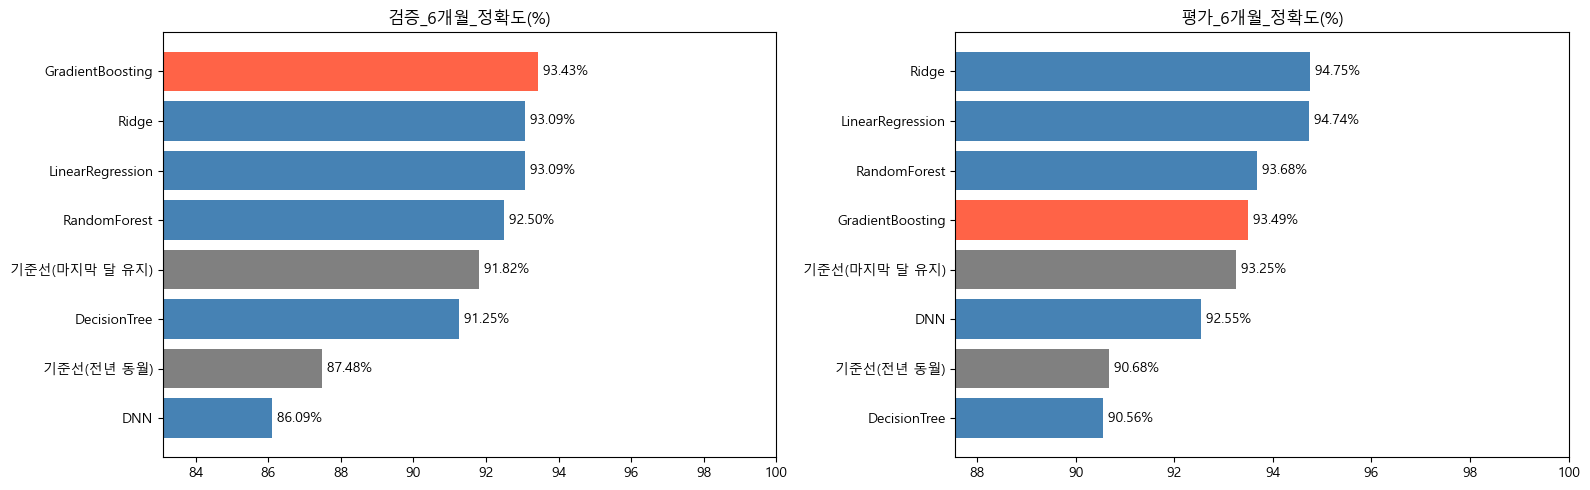

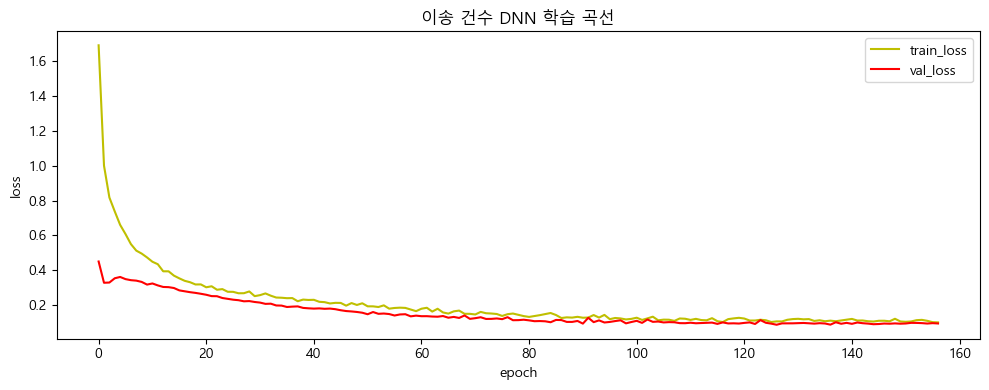

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, ['검증_6개월_정확도(%)', '평가_6개월_정확도(%)']):
    plot_df = score_df.sort_values(col)
    colors = ['gray' if m.startswith('기준선') else ('tomato' if m == best_name else 'steelblue')
              for m in plot_df['모델']]
    ax.barh(plot_df['모델'], plot_df[col], color=colors)
    for i, v in enumerate(plot_df[col]):
        ax.text(v, i, f' {v:.2f}%', va='center')
    ax.set_xlim(plot_df[col].min() - 3, 100)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_model_scores.png')
plt.show()

if 'DNN' in bundles:
    plot_history(bundles['DNN']['history'], '이송 건수 DNN 학습 곡선', RESULT_DIR / 'transport_dnn_history.png')

## A-5. 시각화 ② 평가 기간 결과
- 산점도 : 대각선(y=x)에 가까울수록 정확
- 구별 평균 오차율 : |예측 − 실제| / 실제 × 100
- 결과 csv : `transport_test_predictions.csv` (지역구명 포함)

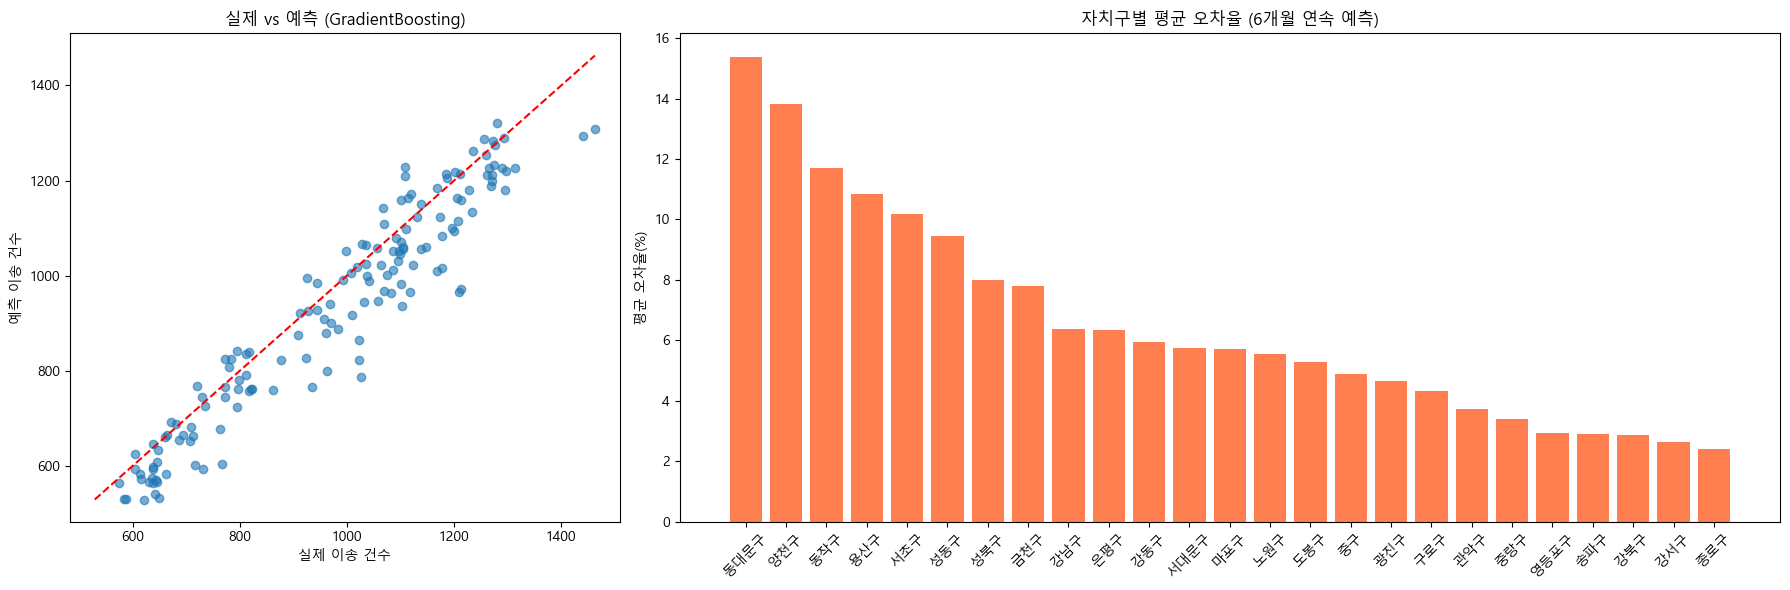

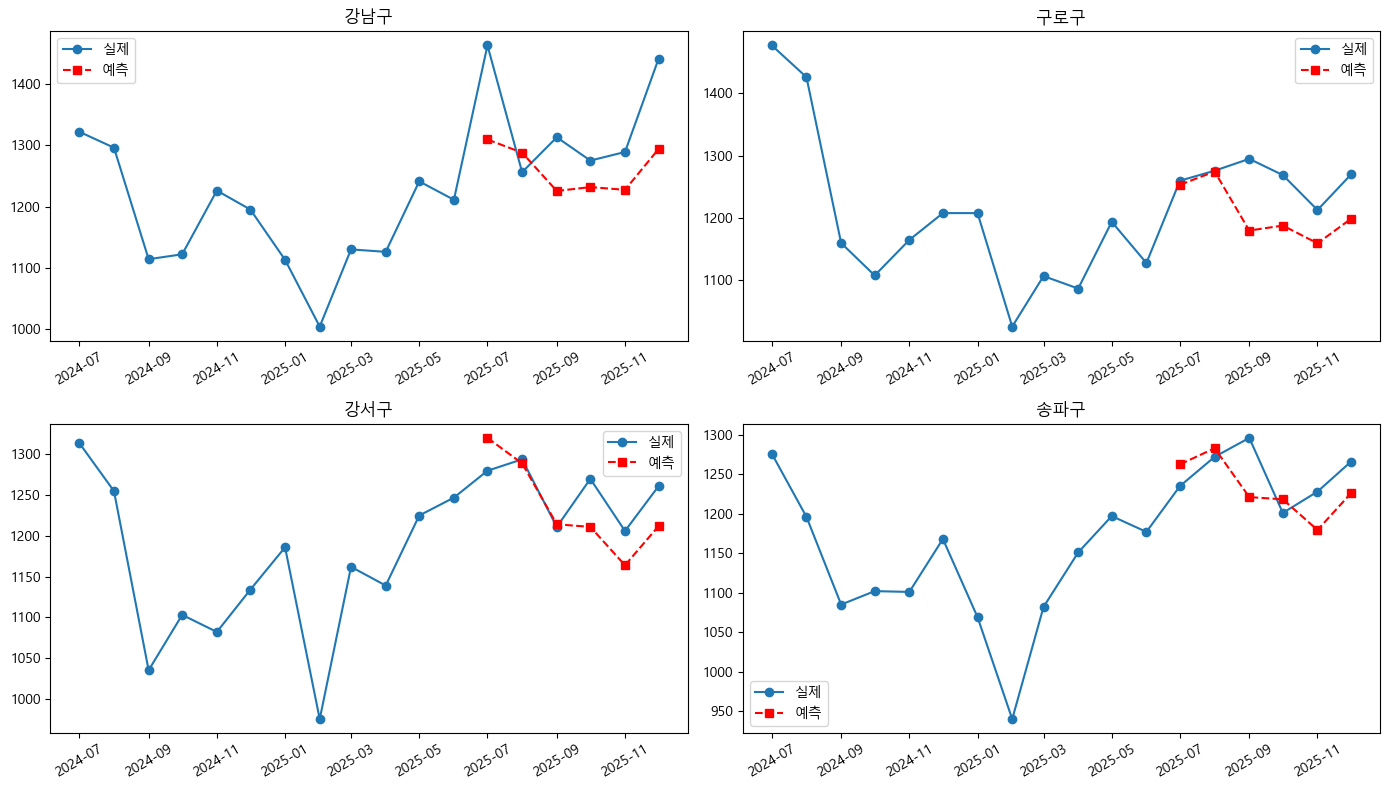

In [7]:
test_result = pd.DataFrame({
    '날짜': best_rec['ds'].dt.strftime('%Y-%m'),
    '지역구명': best_rec['District'],
    '실제_이송건수': best_rec[target].values,
    '예측_이송건수': best_rec['예측'].round(0),
})
test_result['오차율(%)'] = ((test_result['예측_이송건수'] - test_result['실제_이송건수']).abs()
                          / test_result['실제_이송건수'] * 100).round(2)
test_result.to_csv(RESULT_DIR / 'transport_test_predictions.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 2]})
axes[0].scatter(best_rec[target], best_rec['예측'], alpha=0.6)
lim = [best_rec[[target, '예측']].min().min(), best_rec[[target, '예측']].max().max()]
axes[0].plot(lim, lim, 'r--')
axes[0].set_xlabel('실제 이송 건수')
axes[0].set_ylabel('예측 이송 건수')
axes[0].set_title(f'실제 vs 예측 ({best_name})')

gu_err = test_result.groupby('지역구명')['오차율(%)'].mean().sort_values(ascending=False)
axes[1].bar(gu_err.index, gu_err.values, color='coral')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('평균 오차율(%)')
axes[1].set_title('자치구별 평균 오차율 (6개월 연속 예측)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_test_result.png')
plt.show()

top4 = test_result.groupby('지역구명')['실제_이송건수'].sum().sort_values(ascending=False).head(4).index
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, gu in zip(axes.flatten(), top4):
    real = full[(full['District'] == gu) & (full['ds'] >= test_start - pd.DateOffset(months=12))]
    pred = best_rec[best_rec['District'] == gu]
    ax.plot(real['ds'], real[target], marker='o', label='실제')
    ax.plot(pred['ds'], pred['예측'], 'r--', marker='s', label='예측')
    ax.set_title(gu)
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_test_trend.png')
plt.show()

## A-6. 특성 중요도
- 기준 모델 : RandomForest (학습+검증으로 학습한 것)
- 중요도 원리 : 해당 컬럼으로 나눴을 때 오차가 줄어든 양의 합
- 원-핫 컬럼 합산 : `구_`, `월_` 컬럼을 하나로 묶어서 보기

전월_transport_cnt      0.908
월(합계)                 0.040
전년동월_transport_cnt    0.019
전월_동일자치구행정동간이동인구수     0.006
전월_night_pop          0.005
전년_인명갇힘               0.005
전월_일최대인구수             0.005
전월_서울외유입인구수           0.005
전년_승강기사고              0.004
구(합계)                 0.003
dtype: float64


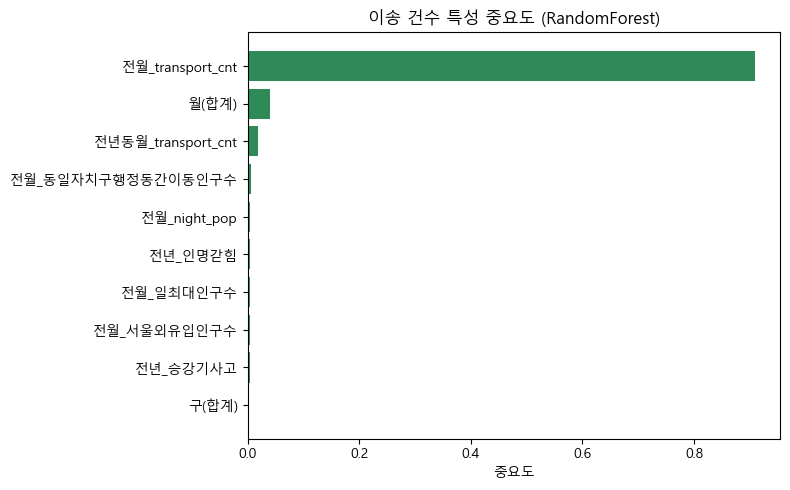

In [8]:
imp = pd.Series(bundles['RandomForest']['model'].feature_importances_, index=bundles['RandomForest']['columns'])
for prefix in ['구_', '월_']:
    cols = [c for c in imp.index if c.startswith(prefix)]
    imp[prefix.rstrip('_') + '(합계)'] = imp[cols].sum()
    imp = imp.drop(cols)
imp = imp.sort_values()
print(imp.sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values, color='seagreen')
plt.xlabel('중요도')
plt.title('이송 건수 특성 중요도 (RandomForest)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_importance.png')
plt.show()

## A-7. 최종 모델 저장 · 구별 미래 예측
- 최종 모델 : 최고 모델을 전체 데이터로 다시 학습
- 저장 후 다시 불러와서 예측 : 저장 파일 동작 확인
- 입력 : `transport_future.csv` (첫 달만 실제 전월 값, 이후는 재귀 예측으로 채움)
- 결과 csv : `transport_forecast_by_gu.csv` (예측월 · 지역구명 · 예측_이송건수)

In [9]:
final = fit_model(best_name, make_X(data), data[target], 'transport')
save_bundle(final, 'transport')

loaded = load_bundle('transport')
check = np.allclose(predict(final, make_X(data.head())), predict(loaded, make_X(data.head())))
print('저장 모델 불러오기 확인 :', check)

fc = predict_months(loaded, future)
forecast = pd.DataFrame({
    '예측월': fc['ds'].dt.strftime('%Y-%m'),
    '지역구명': fc['District'],
    '예측_이송건수': fc['예측'].round(0).astype(int),
    '사용모델': best_name,
})
forecast.to_csv(RESULT_DIR / 'transport_forecast_by_gu.csv', index=False, encoding='utf-8-sig')

missing_gu = sorted(set(GU_LIST) - set(forecast['지역구명']))
if missing_gu:
    print('[주의] 입력 값이 부족해 예측하지 못한 구 :', missing_gu)
print(forecast.pivot(index='지역구명', columns='예측월', values='예측_이송건수'))

저장 모델 불러오기 확인 : True
예측월   2026-01  2026-02  2026-03  2026-04  2026-05  2026-06
지역구명                                                      
강남구      1323     1174     1253     1312     1373     1382
강동구      1125     1037     1100     1100     1178     1175
강북구      1033      933     1003     1018     1097     1082
강서구      1227     1062     1109     1112     1184     1203
관악구      1077      948     1005     1027     1122     1129
광진구       770      707      755      774      859      873
구로구      1201      998     1085     1113     1180     1177
금천구       612      554      576      596      656      654
노원구      1188     1035     1084     1103     1174     1162
도봉구       792      701      734      750      772      783
동대문구     1002      899      923      939      994      991
동작구       740      659      690      692      734      748
마포구      1118      996     1076     1067     1139     1151
서대문구      802      689      706      727      767      751
서초구      1077      965     1016    

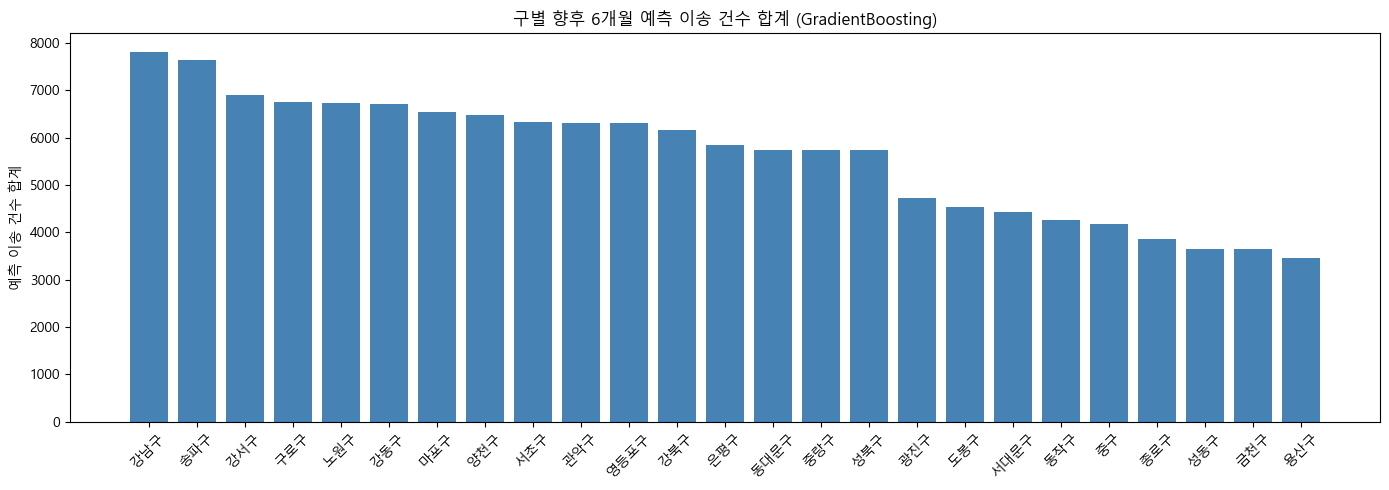

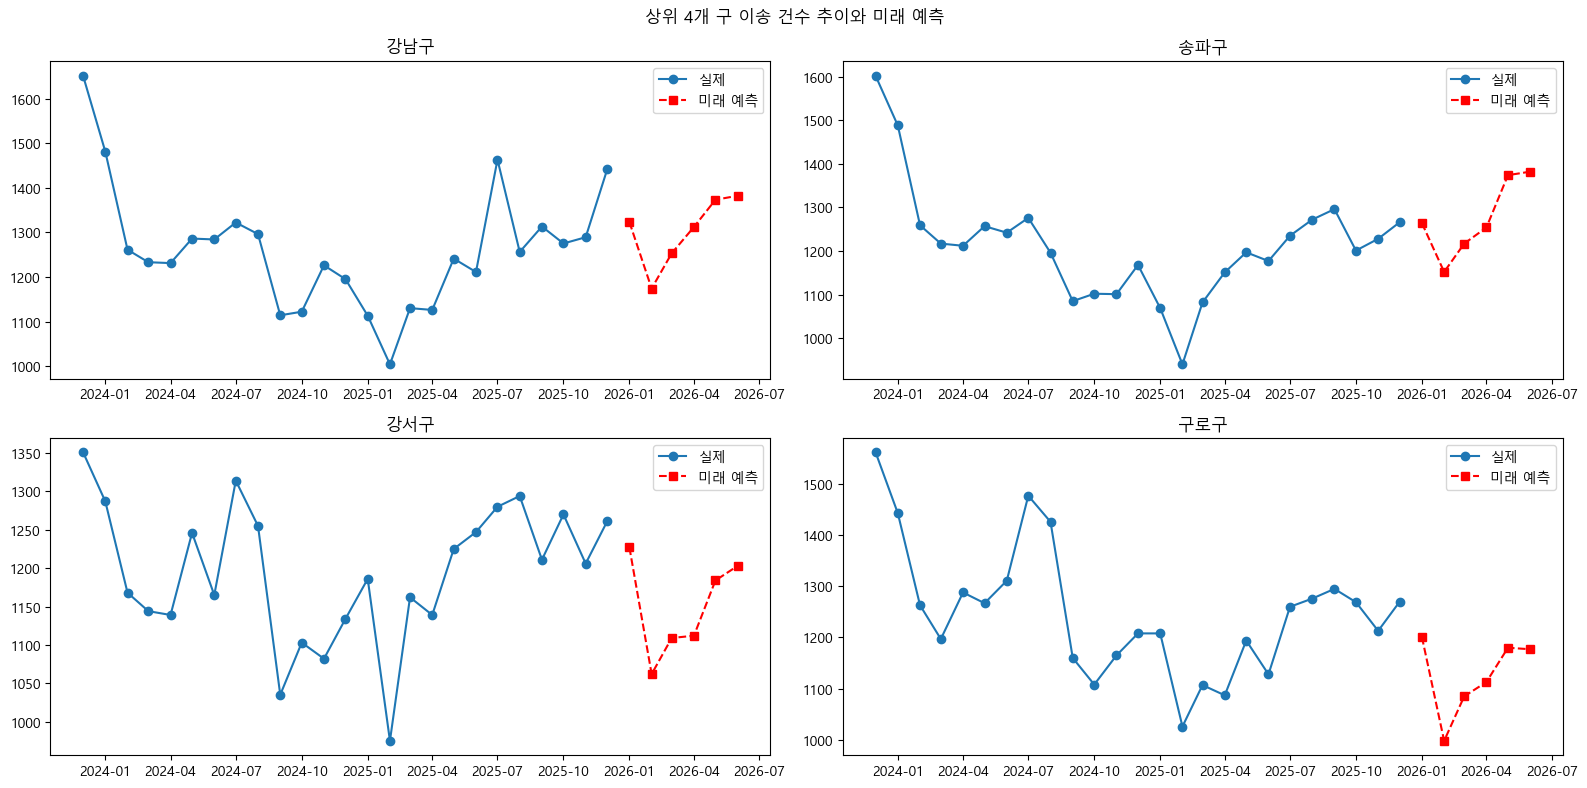

In [10]:
gu_total = forecast.groupby('지역구명')['예측_이송건수'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(gu_total.index, gu_total.values, color='steelblue')
plt.xticks(rotation=45)
plt.ylabel('예측 이송 건수 합계')
plt.title(f'구별 향후 {forecast["예측월"].nunique()}개월 예측 이송 건수 합계 ({best_name})')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_forecast_by_gu.png')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, gu in zip(axes.flatten(), gu_total.index[:4]):
    real = full[(full['District'] == gu) & (full['ds'] >= full['ds'].max() - pd.DateOffset(months=24))]
    fut = forecast[forecast['지역구명'] == gu]
    ax.plot(real['ds'], real[target], marker='o', label='실제')
    ax.plot(pd.to_datetime(fut['예측월']), fut['예측_이송건수'], 'r--', marker='s', label='미래 예측')
    ax.set_title(gu)
    ax.legend()
plt.suptitle('상위 4개 구 이송 건수 추이와 미래 예측')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_forecast_top4.png')
plt.show()

---
# B. 인구 밀집 예측 (자치구 × 일)

## B-1. 데이터 불러오기 · 입력 만들기
- 정답 : `일최대인구수`
- 숫자 특성 : 전처리에서 `선택`된 컬럼
- 요일·월 원-핫 : 숫자(0~6)로 두면 선형 모델이 "일요일 = 월요일 × 6"처럼 잘못 해석
- **날짜순 정렬** : DNN의 `validation_split`이 마지막 20% 행(최근 기간)을 쓰도록

In [11]:
TARGET_POP = '일최대인구수'

pop = pd.read_csv(ML_DATA_DIR / 'population_selected.csv', encoding='utf-8-sig', parse_dates=['ds'])
pop_info = pd.read_csv(ML_DATA_DIR / 'features_population.csv', encoding='utf-8-sig')
pop = pop.sort_values(['ds', 'District']).reset_index(drop=True)

pop['요일'] = pop['ds'].dt.dayofweek
pop['월'] = pop['ds'].dt.month
pop['주말여부'] = (pop['요일'] >= 5).astype(int)

pop_num = pop_info.loc[pop_info['결과'] == '선택', '컬럼'].tolist()
check_features(pop_num, pop, 'population_selected.csv')


def make_pop_X(df):
    df = df.reset_index(drop=True)
    gu_dummy = pd.get_dummies(pd.Categorical(df['District'], categories=GU_LIST), prefix='구', dtype=int)
    day_dummy = pd.get_dummies(pd.Categorical(df['요일'], categories=range(7)), prefix='요일', dtype=int)
    month_dummy = pd.get_dummies(pd.Categorical(df['월'], categories=range(1, 13)), prefix='월', dtype=int)
    return pd.concat([df[pop_num + ['주말여부']], gu_dummy, day_dummy, month_dummy], axis=1)


X_pop = make_pop_X(pop)
y_pop = pop[TARGET_POP]
print('숫자 특성 :', pop_num)
print(X_pop.shape, '/', pop['ds'].min().date(), '~', pop['ds'].max().date())

숫자 특성 : ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff']
(75825, 50) / 2018-04-12 ~ 2026-07-31


## B-2. 자치구별 요일 효과 확인
- 구별 평균으로 나눈 비율 (1보다 크면 평균보다 많음)
- 해석 : 업무지구는 주말 감소, 주거지역은 변화 적음

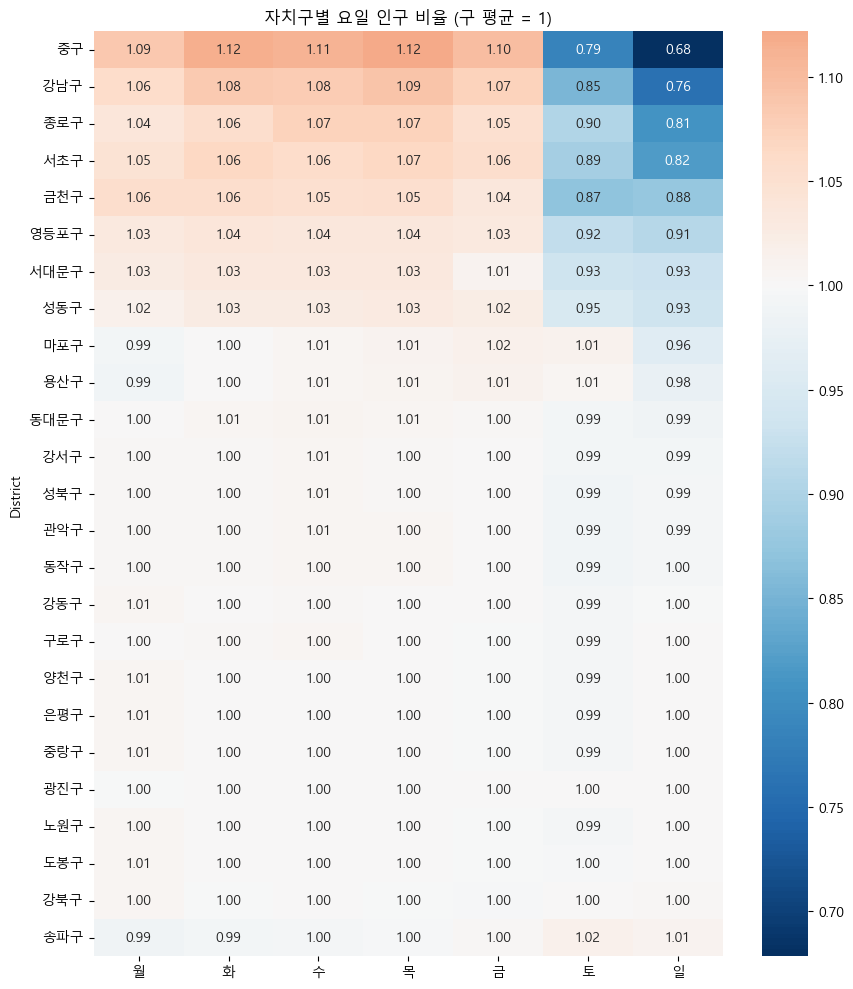

In [12]:
day_ratio = pop.pivot_table(index='District', columns='요일', values=TARGET_POP, aggfunc='mean')
day_ratio = day_ratio.div(day_ratio.mean(axis=1), axis=0)
day_ratio.columns = ['월', '화', '수', '목', '금', '토', '일']
day_ratio = day_ratio.sort_values('일')

plt.figure(figsize=(9, 10))
sns.heatmap(day_ratio, annot=True, fmt='.2f', cmap='RdBu_r', center=1)
plt.title('자치구별 요일 인구 비율 (구 평균 = 1)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_weekday_by_gu.png')
plt.show()

## B-3. 시간순 3단계 분할 · 모델 6종 학습
- 평가 : 마지막 1년 / 검증 : 그 앞 180일 / 학습 : 나머지
- 진행 순서는 A-3과 같음 (검증으로 고르고, 평가로 보고)
- 데이터가 많아서(약 7만 행) 학습에 몇 분 걸릴 수 있음

In [13]:
test_start_pop = pop['ds'].max() - pd.Timedelta(days=POP_TEST_DAYS - 1)
valid_start_pop = test_start_pop - pd.Timedelta(days=POP_VALID_DAYS)

tr = pop['ds'] < valid_start_pop
va = (pop['ds'] >= valid_start_pop) & (pop['ds'] < test_start_pop)
tv = pop['ds'] < test_start_pop
te = pop['ds'] >= test_start_pop
print(f'학습 {tr.sum()}행 / 검증 {va.sum()}행 (시작 {valid_start_pop.date()}) / 평가 {te.sum()}행 (시작 {test_start_pop.date()})')

pop_scores = []
pop_bundles = {}
pop_preds = {}
for name in MODEL_NAMES:
    b_train = fit_model(name, X_pop[tr], y_pop[tr], 'population')
    v = evaluate(y_pop[va], predict(b_train, X_pop[va]))

    b_tv = fit_model(name, X_pop[tv], y_pop[tv], 'population')
    pop_bundles[name] = b_tv
    pop_preds[name] = predict(b_tv, X_pop[te])
    t = evaluate(y_pop[te], pop_preds[name])

    pop_scores.append({'모델': name, '검증_정확도(%)': v['정확도(%)'], '평가_정확도(%)': t['정확도(%)'],
                       '평가_R2': t['R2'], '평가_MAE': t['MAE'], '평가_RMSE': t['RMSE']})
    print(f'{name:18s} 완료')

# 기준선 : 7일 전 같은 요일 값 그대로
if '7일전_일최대인구수' in pop.columns:
    v = evaluate(y_pop[va], pop.loc[va, '7일전_일최대인구수'])
    t = evaluate(y_pop[te], pop.loc[te, '7일전_일최대인구수'])
    pop_scores.append({'모델': '기준선(7일 전 그대로)', '검증_정확도(%)': v['정확도(%)'],
                       '평가_정확도(%)': t['정확도(%)'], '평가_R2': t['R2'], '평가_MAE': t['MAE'],
                       '평가_RMSE': t['RMSE']})

pop_score_df = pd.DataFrame(pop_scores).sort_values('검증_정확도(%)', ascending=False).reset_index(drop=True)
pop_score_df.to_csv(RESULT_DIR / 'population_model_scores.csv', index=False, encoding='utf-8-sig')
print(pop_score_df.round(3).to_string(index=False))

pop_best = pop_score_df[pop_score_df['모델'].isin(MODEL_NAMES)].iloc[0]['모델']
pop_best_pred = pop_preds[pop_best]
print('\n최고 모델 (검증 기준) :', pop_best)

학습 62200행 / 검증 4500행 (시작 2025-02-02) / 평가 9125행 (시작 2025-08-01)
LinearRegression   완료
Ridge              완료
DecisionTree       완료
RandomForest       완료
GradientBoosting   완료
DNN                완료
              모델  검증_정확도(%)  평가_정확도(%)  평가_R2    평가_MAE   평가_RMSE
    RandomForest     98.589     98.163  0.986  8836.005 21081.660
GradientBoosting     98.356     97.970  0.986  9463.479 20994.535
    DecisionTree     97.987     97.515  0.976 11415.450 27054.046
             DNN     97.978     97.790  0.984 10107.044 22154.070
   기준선(7일 전 그대로)     97.862     97.545  0.952 12015.489 38631.152
           Ridge     97.337     97.112  0.969 14036.455 30769.442
LinearRegression     97.335     97.110  0.969 14041.460 30769.501

최고 모델 (검증 기준) : RandomForest


## B-4. 시각화 ① 모델 비교 · DNN 학습 곡선

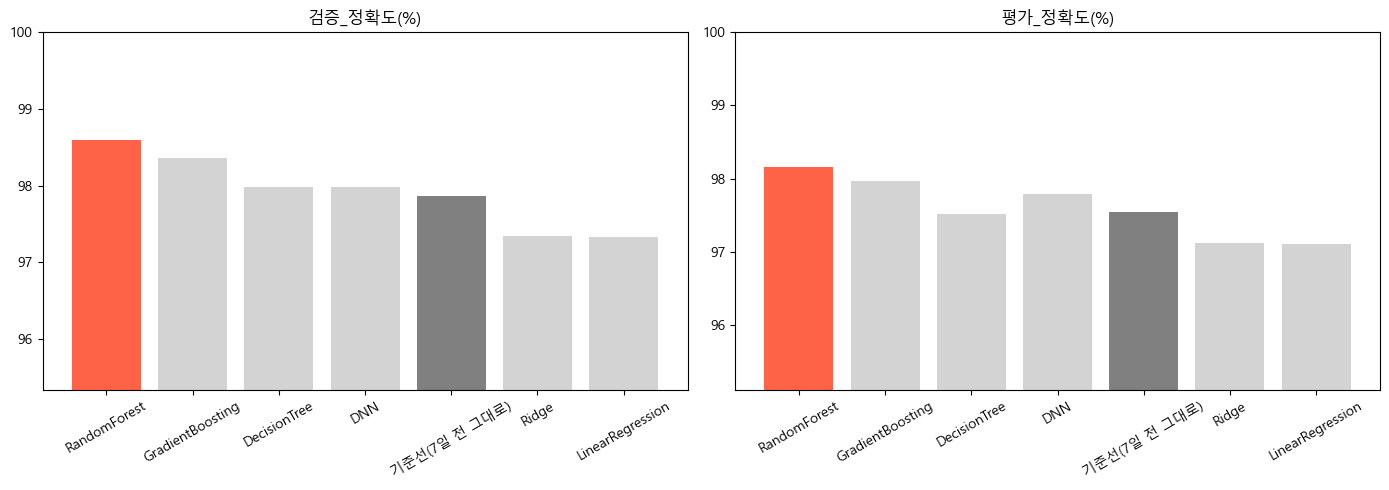

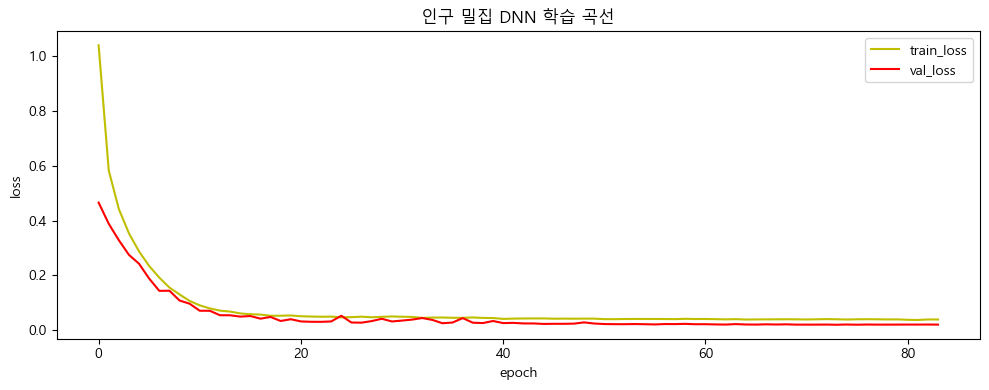

In [14]:
colors = ['gray' if m.startswith('기준선') else ('tomato' if m == pop_best else 'lightgray')
          for m in pop_score_df['모델']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['검증_정확도(%)', '평가_정확도(%)']):
    ax.bar(pop_score_df['모델'], pop_score_df[col], color=colors)
    ax.set_title(col)
    ax.set_ylim(pop_score_df[col].min() - 2, 100)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_model_scores.png')
plt.show()

if 'DNN' in pop_bundles:
    plot_history(pop_bundles['DNN']['history'], '인구 밀집 DNN 학습 곡선', RESULT_DIR / 'population_dnn_history.png')

## B-5. 시각화 ② 평가 기간 결과
- 결과 csv : `population_test_predictions.csv` (지역구명 포함)

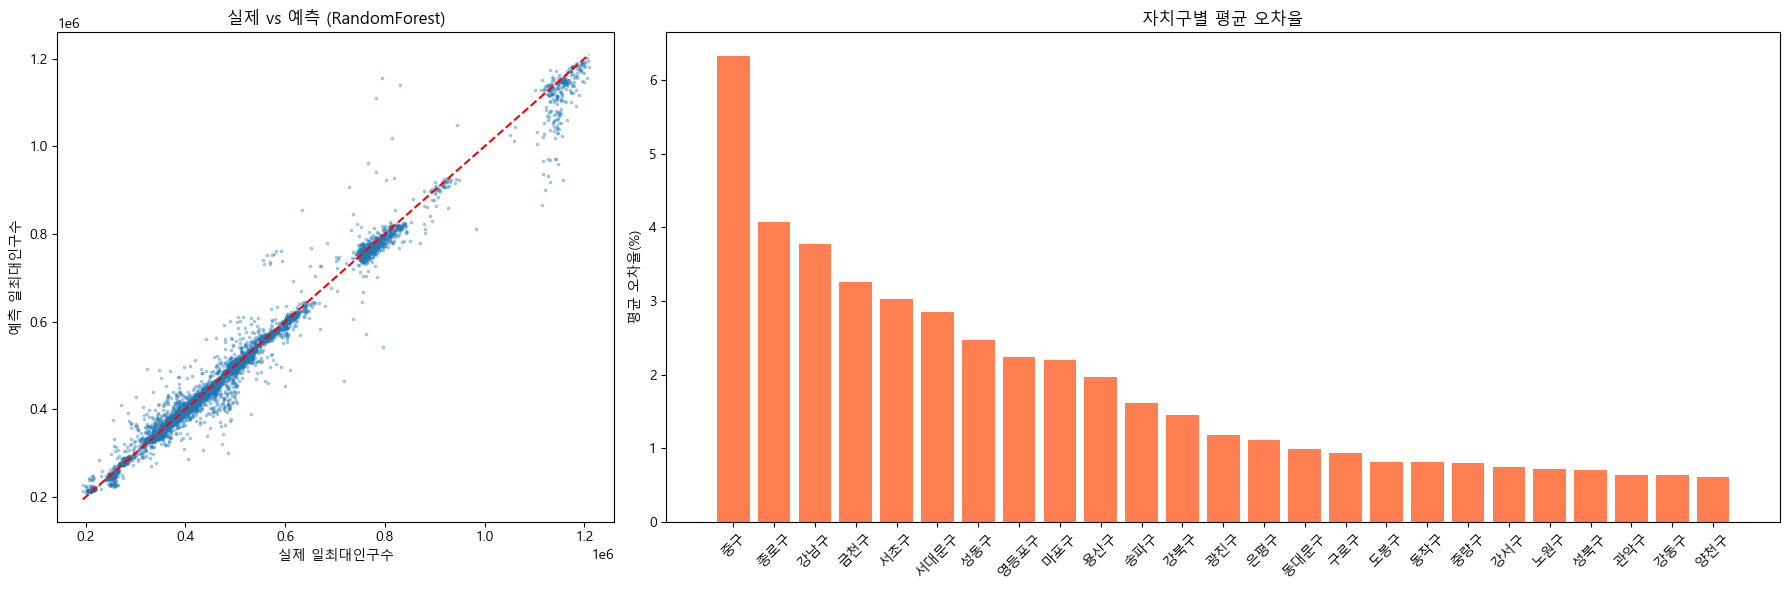

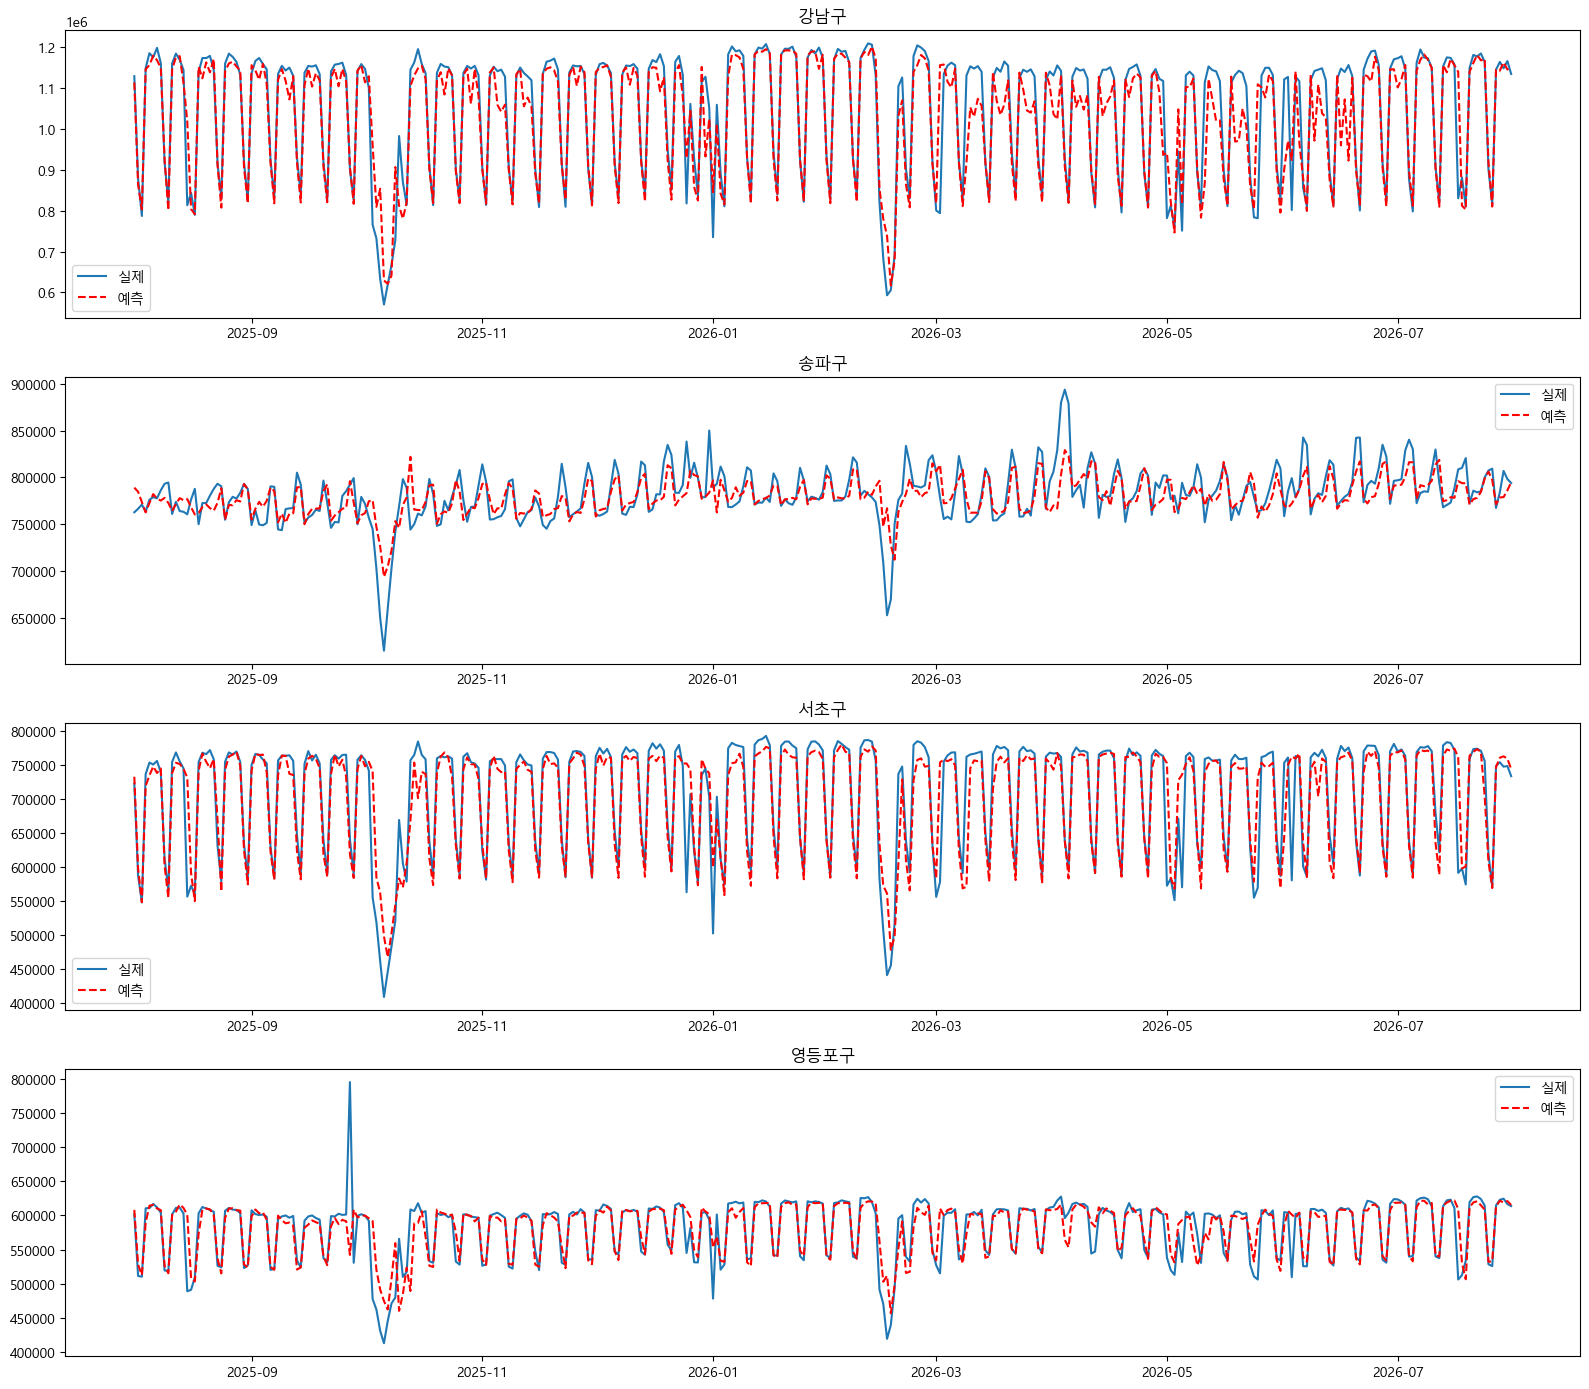

오차율 상위 10일 (서울 평균)
날짜
2025-10-06    13.07
2026-02-16    12.36
2025-10-15    12.06
2025-10-05    11.31
2025-10-03     9.19
2025-10-04     9.02
2026-01-01     8.24
2026-03-02     8.02
2026-06-03     7.97
2026-07-17     7.85


In [15]:
pop_result = pd.DataFrame({
    '날짜': pop.loc[te, 'ds'].dt.strftime('%Y-%m-%d').values,
    '지역구명': pop.loc[te, 'District'].values,
    '실제_일최대인구수': y_pop[te].values.round(0),
    '예측_일최대인구수': pop_best_pred.round(0),
})
pop_result['오차율(%)'] = ((pop_result['예측_일최대인구수'] - pop_result['실제_일최대인구수']).abs()
                         / pop_result['실제_일최대인구수'] * 100).round(2)
pop_result.to_csv(RESULT_DIR / 'population_test_predictions.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 2]})
axes[0].scatter(y_pop[te], pop_best_pred, s=3, alpha=0.3)
lim = [y_pop[te].min(), y_pop[te].max()]
axes[0].plot(lim, lim, 'r--')
axes[0].set_xlabel('실제 일최대인구수')
axes[0].set_ylabel('예측 일최대인구수')
axes[0].set_title(f'실제 vs 예측 ({pop_best})')

gu_err = pop_result.groupby('지역구명')['오차율(%)'].mean().sort_values(ascending=False)
axes[1].bar(gu_err.index, gu_err.values, color='coral')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('평균 오차율(%)')
axes[1].set_title('자치구별 평균 오차율')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_test_result.png')
plt.show()

top4 = pop_result.groupby('지역구명')['실제_일최대인구수'].mean().sort_values(ascending=False).head(4).index
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, gu in zip(axes, top4):
    part = pop_result[pop_result['지역구명'] == gu]
    ax.plot(pd.to_datetime(part['날짜']), part['실제_일최대인구수'], label='실제')
    ax.plot(pd.to_datetime(part['날짜']), part['예측_일최대인구수'], 'r--', label='예측')
    ax.set_title(gu)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_trend.png')
plt.show()

# 오차가 큰 날 확인 : 공휴일·명절이 많으면 공휴일 컬럼 추가 검토
print('오차율 상위 10일 (서울 평균)')
print(pop_result.groupby('날짜')['오차율(%)'].mean().nlargest(10).round(2).to_string())

## B-6. 특성 중요도 · 최종 모델 저장
- 원-핫 컬럼 합산 : `구_`, `요일_`, `월_`
- 최종 모델 : 전체 기간으로 다시 학습 후 저장, 다시 불러와 동작 확인

7일전_일최대인구수           0.960
전일_night_pop         0.014
전일_pop_diff          0.011
전일_일최대이동인구수          0.004
구(합계)                0.004
전일_동일자치구행정동간이동인구수    0.003
요일(합계)               0.003
주말여부                 0.002
월(합계)                0.001
dtype: float64


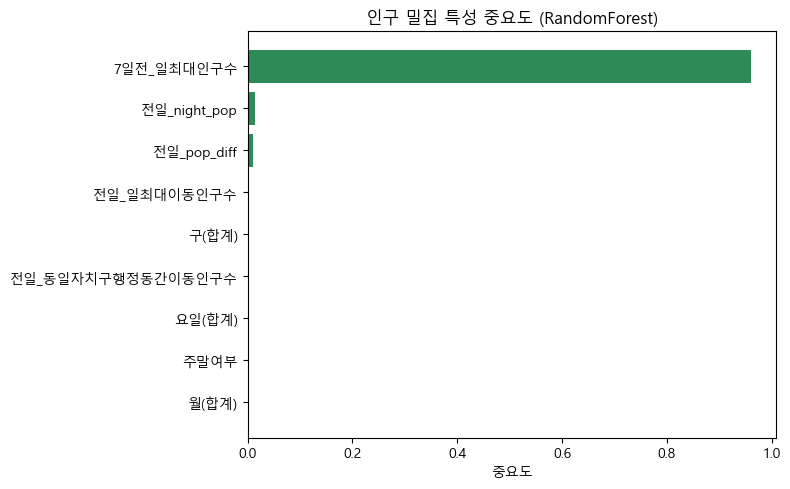

저장 모델 불러오기 확인 : True


In [16]:
imp = pd.Series(pop_bundles['RandomForest']['model'].feature_importances_, index=X_pop.columns)
for prefix in ['구_', '요일_', '월_']:
    cols = [c for c in imp.index if c.startswith(prefix)]
    imp[prefix.rstrip('_') + '(합계)'] = imp[cols].sum()
    imp = imp.drop(cols)
imp = imp.sort_values()
print(imp.sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values, color='seagreen')
plt.xlabel('중요도')
plt.title('인구 밀집 특성 중요도 (RandomForest)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_importance.png')
plt.show()

pop_final = fit_model(pop_best, X_pop, y_pop, 'population')
save_bundle(pop_final, 'population')
pop_loaded = load_bundle('population')
print('저장 모델 불러오기 확인 :',
      np.allclose(predict(pop_final, X_pop.head()), predict(pop_loaded, X_pop.head())))

---
## 결과 요약

In [17]:
print('[이송 건수] 최고 모델 :', best_name)
print(score_df.round(2).to_string(index=False))
print('\n[인구 밀집] 최고 모델 :', pop_best)
print(pop_score_df.round(2).to_string(index=False))

print('\n[결과 파일] ->', RESULT_DIR)
for f in ['transport_model_scores.csv', 'transport_test_predictions.csv', 'transport_forecast_by_gu.csv',
          'population_model_scores.csv', 'population_test_predictions.csv']:
    print('  ', f)

[이송 건수] 최고 모델 : GradientBoosting
              모델  검증_6개월_정확도(%)  평가_6개월_정확도(%)  평가_6개월_MAE  평가_1개월_정확도(%)  평가_1개월_R2
GradientBoosting          93.43          93.49       62.28          95.22       0.94
           Ridge          93.09          94.75       49.72          94.97       0.93
LinearRegression          93.09          94.74       49.85          94.97       0.93
    RandomForest          92.50          93.68       59.31          95.50       0.94
   기준선(마지막 달 유지)          91.82          93.25       66.35          95.41       0.93
    DecisionTree          91.25          90.56       90.98          94.71       0.92
      기준선(전년 동월)          87.48          90.68       90.85          90.68       0.78
             DNN          86.09          92.55       72.98          94.85       0.93

[인구 밀집] 최고 모델 : RandomForest
              모델  검증_정확도(%)  평가_정확도(%)  평가_R2   평가_MAE  평가_RMSE
    RandomForest      98.59      98.16   0.99  8836.01 21081.66
GradientBoosting      98.36      97.97   0.9

## 참고
- 관할 변경 4개 구(성동·광진·금천·구로) : 개서 이후 구간만 사용 → 다른 구보다 학습 행이 적음
- 2024년 초 이송 건수가 크게 줄어든 구간 있음 → 전년 동월 값이 덜 맞을 수 있음
- 인구 밀집 : 공휴일 정보가 없어 명절 연휴처럼 급감하는 날은 예측이 늦게 따라감